### Notebook Overview

Building upon the linear baseline established in Stage 3, this notebook explores a variety of non-linear and ensemble machine learning algorithms to improve predictive performance on the Spotify Churn dataset. The feature set (231 features) is high-dimensional and has class imbalance, we will check if non-linear models fare better.

#### Objectives of this Phase

Implement and evaluate multiple classifiers, including KNN, Decision Trees, SVM (RBF), Random Forests, AdaBoost, and Gradient Boosting.

Utilize GridSearchCV to perform exhaustive hyperparameter tuning for each model, identifying the optimal configuration for depth, estimators, and regularization.

Apply Stratified K-Fold Cross-Validation during the tuning process to ensure model stability across the imbalanced 3:1 dataset.

Optimize specifically for the F1-Score to maximize the detection of churners while controlling for false positives.

Create a comparison table (Model, Train Time, Train Accuracy, Test Accuracy, F1-Score) to justify the final model choice.

### Load the Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load model-ready features and target
X = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/X_final_processed.parquet')
y = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/y_final_target.parquet').squeeze()

print(f"Features loaded: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features loaded: (8000, 22)
Target distribution:
is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64


### Stratified train-test split

In [2]:
# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 6400 rows
Testing set size: 1600 rows


### Comparison of Models

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_custom_cm(model, X_test, y_test, model_name="Model"):
    """
    Generates and plots a confusion matrix for a given model.
    
    Parameters:
    model: The classifier
    X_test: Test features.
    y_test: True labels for the test set.
    model_name: String name for the plot title.
    """
    # 1. Generate predictions
    y_pred = model.predict(X_test)
    
    # 2. Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Create the display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['Not Churned', 'Churned'])
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax)
    
    plt.title(f'Confusion Matrix: {model_name}')
    plt.grid(False)

    # Save logic
    file_path = os.path.join(viz_folder, f"{model_name.replace(' ', '_')}_CM.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {file_path}")

In [4]:
from sklearn.metrics import RocCurveDisplay
def plot_roc(model, X_test, y_test, model_name):
    """Generates, saves, and displays an ROC curve."""
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    plt.plot([0, 1], [0, 1], 'r--') # Random guess line
    
    title = f'{model_name} ROC Curve'
    plt.title(title)
    
    # Save logic
    file_path = os.path.join(viz_folder, f"{model_name.replace(' ', '_')}_ROC.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {file_path}")

### Setup the Directory to save plots

In [5]:
import os

# Define the folder name
viz_folder = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures'

# Create the folder if it doesn't already exist
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

### Setup Stratified K Fold

In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Setup a dataframe to store scores

In [26]:
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score

# Initialize the master comparison table
comparison_df = pd.DataFrame(columns=['Model', 'F1-Score', 'Recall', 'Precision', 'AUC', 'Accuracy'])

In [27]:
def update_comparison_table(model_object, model_name, X_test, y_test):
    global comparison_df
    
    # 1. Generate predictions
    y_pred = model_object.predict(X_test)
    y_proba = model_object.predict_proba(X_test)[:, 1]
    
    # 2. Calculate metrics
    new_row = {
        'Model': model_name,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred)
    }
    
    # 3. Append to the dataframe
    comparison_df = pd.concat([comparison_df, pd.DataFrame([new_row])], ignore_index=True)
    
    # 4. Display the updated table sorted by Recall (your primary goal)
    return comparison_df.sort_values(by='Recall', ascending=False)

### KNN

Best KNN Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best Cross-Val F1 Score: 0.2092


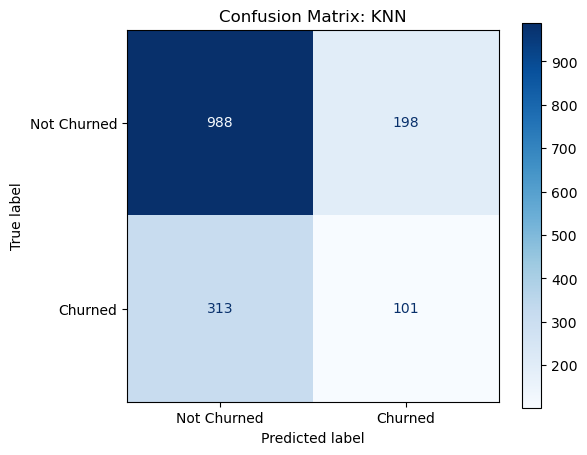

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/KNN_CM.png


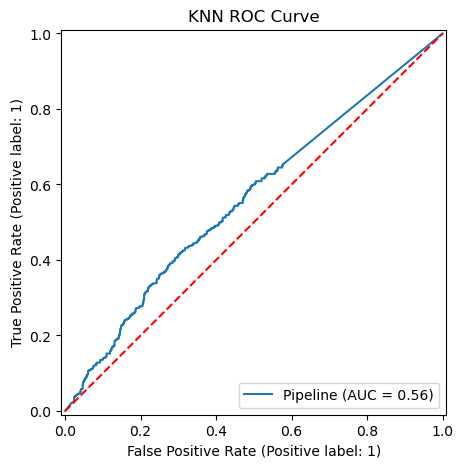

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/KNN_ROC.png


/var/folders/z6/g_qpk8_x2jj03h_r6f2g_8nw0000gn/T/ipykernel_39909/4039802866.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([comparison_df, pd.DataFrame([new_row])], ignore_index=True)


,Model,F1-Score,Recall,Precision,AUC,Accuracy
0,KNN,0.28331,0.243961,0.337793,0.561169,0.680625


In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Define the Pipeline
knn_pipe = Pipeline([
    ('knn', KNeighborsClassifier())
])

# 2. Define the Parameter Grid
# We test different k values and weights (uniform vs distance-based)
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Initialize GridSearchCV
# Using the 'skf' StratifiedKFold
knn_grid = GridSearchCV(
    knn_pipe, 
    knn_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
knn_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {knn_grid.best_score_:.4f}")

# 6. Visualize Results using your custom functions
plot_custom_cm(knn_grid.best_estimator_, X_test, y_test, "KNN")
plot_roc(knn_grid.best_estimator_, X_test, y_test, "KNN")

# Add scores on comparison table
update_comparison_table(knn_grid.best_estimator_, "KNN", X_test, y_test)

### Decision Trees

Best Decision Tree Parameters: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_split': 2}
Best Cross-Val F1 Score: 0.3744


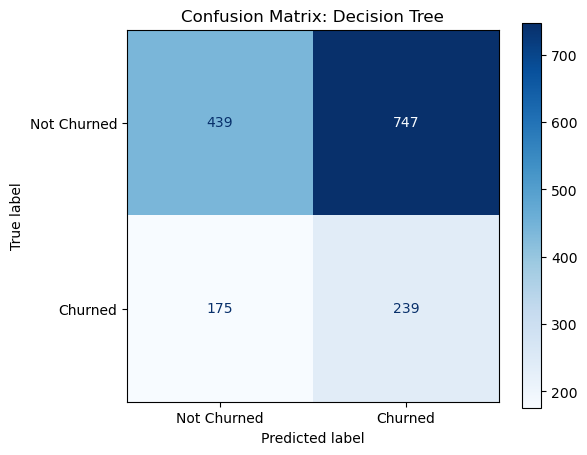

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Decision_Tree_CM.png


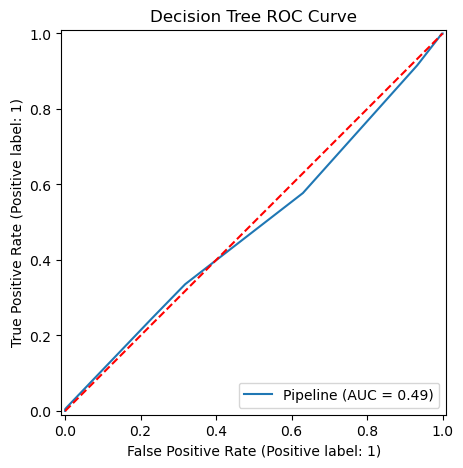

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Decision_Tree_ROC.png


,Model,F1-Score,Recall,Precision,AUC,Accuracy
1,Decision Tree,0.341429,0.577295,0.242394,0.487401,0.423750
0,KNN,0.283310,0.243961,0.337793,0.561169,0.680625


In [29]:
from sklearn.tree import DecisionTreeClassifier

# 1. Define the Pipeline
dt_pipe = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# We focus on depth and splitting criteria to prevent overfitting
dt_param_grid = {
    'dt__max_depth': [3, 5, 10, 20, None],
    'dt__min_samples_split': [2, 10, 20],
    'dt__class_weight': ['balanced', None], # 'balanced' helps with our churn class
    'dt__criterion': ['gini', 'entropy']
}

# 3. Initialize GridSearchCV
dt_grid = GridSearchCV(
    dt_pipe, 
    dt_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
dt_grid.fit(X_train, y_train)

# 5. Report Results
print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {dt_grid.best_score_:.4f}")

# 6. Visualize
plot_custom_cm(dt_grid.best_estimator_, X_test, y_test, "Decision Tree")
plot_roc(dt_grid.best_estimator_, X_test, y_test, "Decision Tree")

# Add scores on comparison table
update_comparison_table(dt_grid.best_estimator_, "Decision Tree", X_test, y_test)

### SVM (RBF)

Best SVM Parameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale'}
Best Cross-Val F1 Score: 0.3327


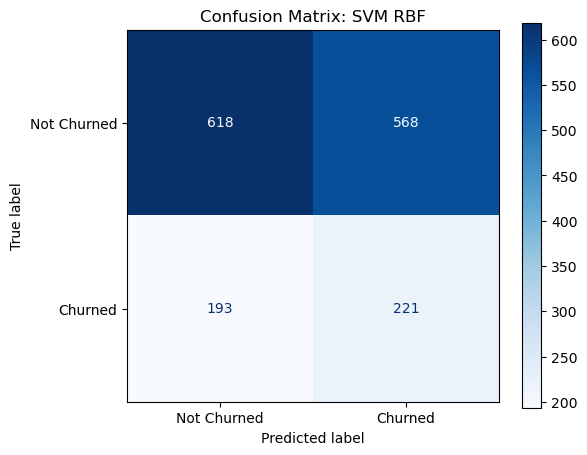

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/SVM_RBF_CM.png


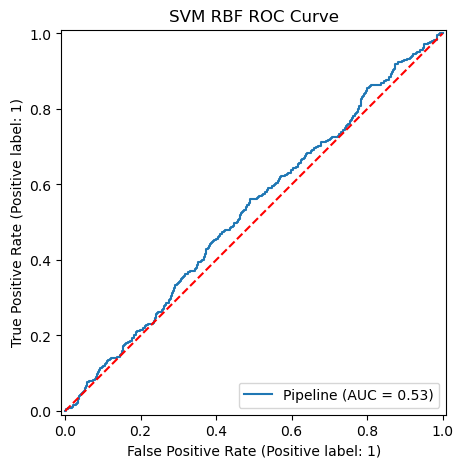

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/SVM_RBF_ROC.png


,Model,F1-Score,Recall,Precision,AUC,Accuracy
1,Decision Tree,0.341429,0.577295,0.242394,0.487401,0.423750
2,SVM,0.367415,0.533816,0.280101,0.527678,0.524375
0,KNN,0.283310,0.243961,0.337793,0.561169,0.680625


In [30]:
from sklearn.svm import SVC

# 1. Define Pipeline
svm_pipe = Pipeline([
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# 2. Define Parameter Grid
# C: Regularization (Higher = less regularization)
# gamma: How far the influence of a single training example reaches
svm_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': ['balanced'] 
}

# 3. GridSearchCV
svm_grid = GridSearchCV(
    svm_pipe, 
    svm_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit
svm_grid.fit(X_train, y_train)

# 5. Results
print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {svm_grid.best_score_:.4f}")

# 6. Visualize
plot_custom_cm(svm_grid.best_estimator_, X_test, y_test, "SVM RBF")
plot_roc(svm_grid.best_estimator_, X_test, y_test, "SVM RBF")

# Add scores on comparison table
update_comparison_table(svm_grid.best_estimator_, "SVM", X_test, y_test)

### Random Forest

Best RF Parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Best Cross-Val F1 Score: 0.2354


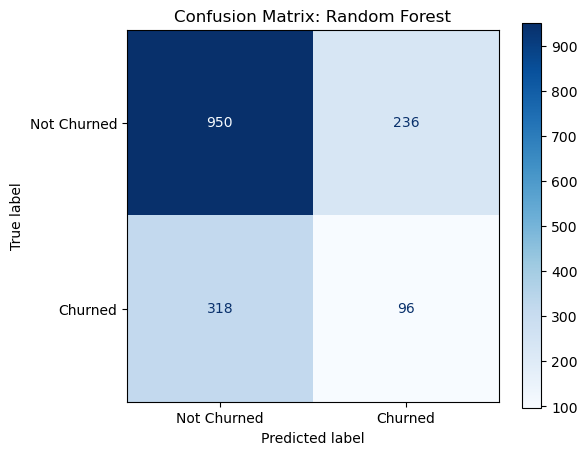

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Random_Forest_CM.png


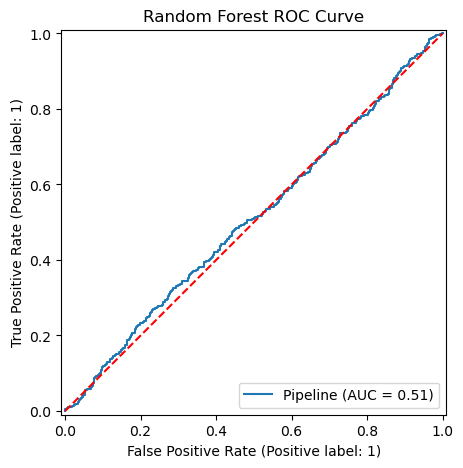

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Random_Forest_ROC.png


,Model,F1-Score,Recall,Precision,AUC,Accuracy
1,Decision Tree,0.341429,0.577295,0.242394,0.487401,0.423750
2,SVM,0.367415,0.533816,0.280101,0.527678,0.524375
0,KNN,0.283310,0.243961,0.337793,0.561169,0.680625
3,Random Forest,0.257373,0.231884,0.289157,0.509073,0.653750


In [31]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Pipeline
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# n_estimators: Number of trees in the forest
# max_depth: Limits tree growth to prevent overfitting
# class_weight: 'balanced' is crucial since we have fewer churners
rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__class_weight': ['balanced']
}

# 3. Initialize GridSearchCV with n_jobs=-1 for speed
rf_grid = GridSearchCV(
    rf_pipe, 
    rf_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
rf_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {rf_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(rf_grid.best_estimator_, X_test, y_test, "Random Forest")
plot_roc(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

# Add scores on comparison table
update_comparison_table(rf_grid.best_estimator_, "Random Forest", X_test, y_test)

### AdaBoost

Best AdaBoost Parameters: {'ada__learning_rate': 1.0, 'ada__n_estimators': 50}
Best Cross-Val F1 Score: 0.0047


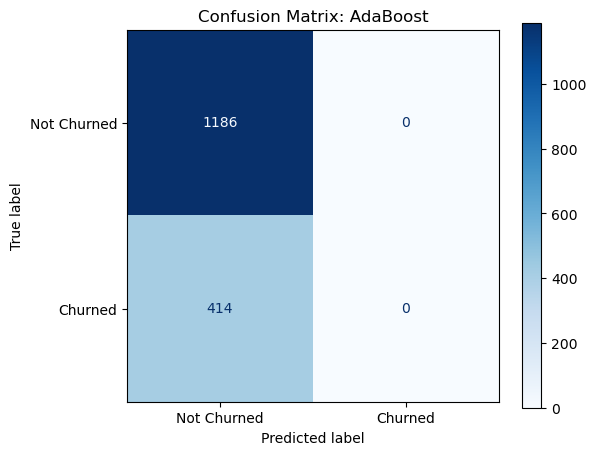

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/AdaBoost_CM.png


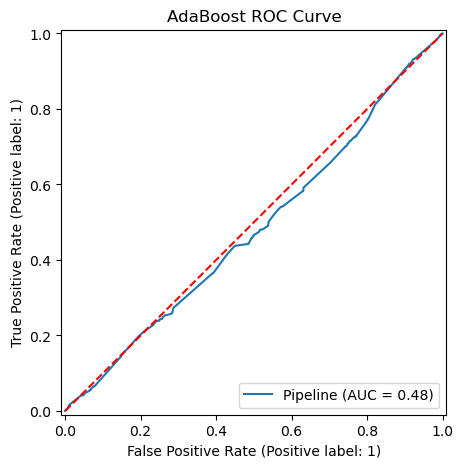

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/AdaBoost_ROC.png


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,F1-Score,Recall,Precision,AUC,Accuracy
1,Decision Tree,0.341429,0.577295,0.242394,0.487401,0.423750
2,SVM,0.367415,0.533816,0.280101,0.527678,0.524375
0,KNN,0.283310,0.243961,0.337793,0.561169,0.680625
3,Random Forest,0.257373,0.231884,0.289157,0.509073,0.653750
4,AdaBoost,0.000000,0.000000,0.000000,0.481722,0.741250


In [32]:
from sklearn.ensemble import AdaBoostClassifier

# 1. Define the Pipeline
ada_pipe = Pipeline([
    ('ada', AdaBoostClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# n_estimators: Number of boosting stages
# learning_rate: Shrinks the contribution of each classifier (trade-off with n_estimators)
ada_param_grid = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.01, 0.1, 1.0],
}

# 3. Initialize GridSearchCV
ada_grid = GridSearchCV(
    ada_pipe, 
    ada_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
ada_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best AdaBoost Parameters: {ada_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {ada_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(ada_grid.best_estimator_, X_test, y_test, "AdaBoost")
plot_roc(ada_grid.best_estimator_, X_test, y_test, "AdaBoost")

# Add scores on comparison table
update_comparison_table(ada_grid.best_estimator_, "AdaBoost", X_test, y_test)

### Gradient Boosting

Best Gradient Boosting Parameters: {'gb__class_weight': 'balanced', 'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__max_iter': 100}
Best Cross-Val F1 Score: 0.3536


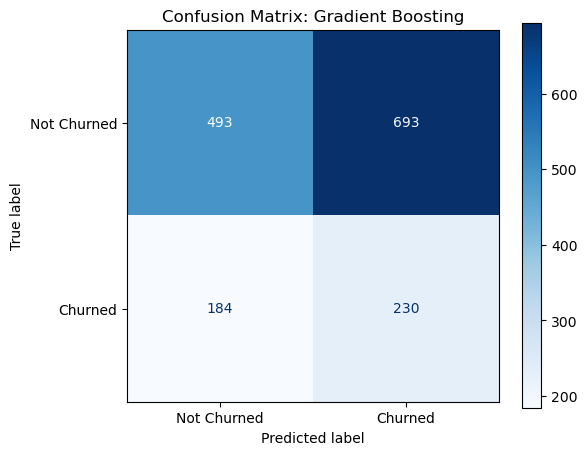

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Gradient_Boosting_CM.png


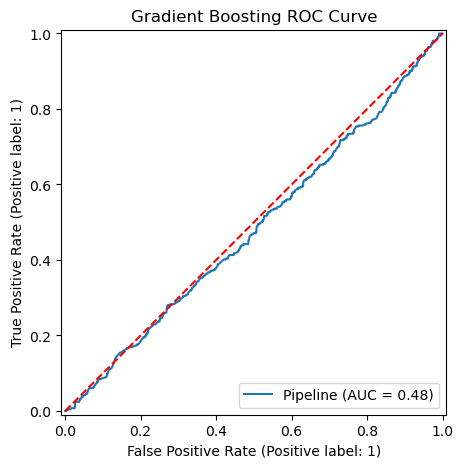

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Gradient_Boosting_ROC.png


,Model,F1-Score,Recall,Precision,AUC,Accuracy
1,Decision Tree,0.341429,0.577295,0.242394,0.487401,0.423750
5,Gradient Boosting,0.344054,0.555556,0.249187,0.482695,0.451875
2,SVM,0.367415,0.533816,0.280101,0.527678,0.524375
0,KNN,0.283310,0.243961,0.337793,0.561169,0.680625
3,Random Forest,0.257373,0.231884,0.289157,0.509073,0.653750
4,AdaBoost,0.000000,0.000000,0.000000,0.481722,0.741250


In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Define the Pipeline
gb_pipe = Pipeline([
    ('gb', HistGradientBoostingClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# max_iter: Equivalent to n_estimators (number of boosting rounds)
# max_depth: Limits the complexity of individual trees
# learning_rate: Controls how much each tree contributes
gb_param_grid = {
    'gb__max_iter': [100, 200],
    'gb__learning_rate': [0.01, 0.1],
    'gb__max_depth': [3, 5, 10],
    'gb__class_weight': ['balanced', None]
}

# 3. Initialize GridSearchCV
gb_grid = GridSearchCV(
    gb_pipe, 
    gb_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
gb_grid.fit(X_train, y_train)

# 5. Report Results
print(f"Best Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {gb_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")
plot_roc(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")

# Add scores on comparison table
update_comparison_table(gb_grid.best_estimator_, "Gradient Boosting", X_test, y_test)

### Comparison of all the models

In [ ]:
# 1. Add your manual score ONLY if it isn't already there to avoid duplicates
balanced_lr_name = "Balanced LR (Baseline)"
if balanced_lr_name not in comparison_df['Model'].values:
    balanced_lr_score = { 
        "Model": balanced_lr_name,
        "F1-Score": 0.34324553950722175,
        "Recall": 0.48792270531400966,
        "Precision": 0.26474442988204455,
        "AUC": 0.5074520777834803,
        "Accuracy": 0.516875
    }
comparison_df = pd.concat([comparison_df, pd.DataFrame([balanced_lr_score])], ignore_index=True)


--- Final Model Comparison: Fewer Features Strategy ---


,Model,F1-Score,Recall,Precision,AUC,Accuracy
2,SVM,0.3674,0.5338,0.2801,0.5277,0.5244
5,Gradient Boosting,0.3441,0.5556,0.2492,0.4827,0.4519
6,Balanced LR (Baseline),0.3432,0.4879,0.2647,0.5075,0.5169
1,Decision Tree,0.3414,0.5773,0.2424,0.4874,0.4238
0,KNN,0.2833,0.2440,0.3378,0.5612,0.6806
3,Random Forest,0.2574,0.2319,0.2892,0.5091,0.6538
4,AdaBoost,0.0000,0.0000,0.0000,0.4817,0.7412


Chart successfully saved to: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Final_Model_Comparison_FewerFeatures.png


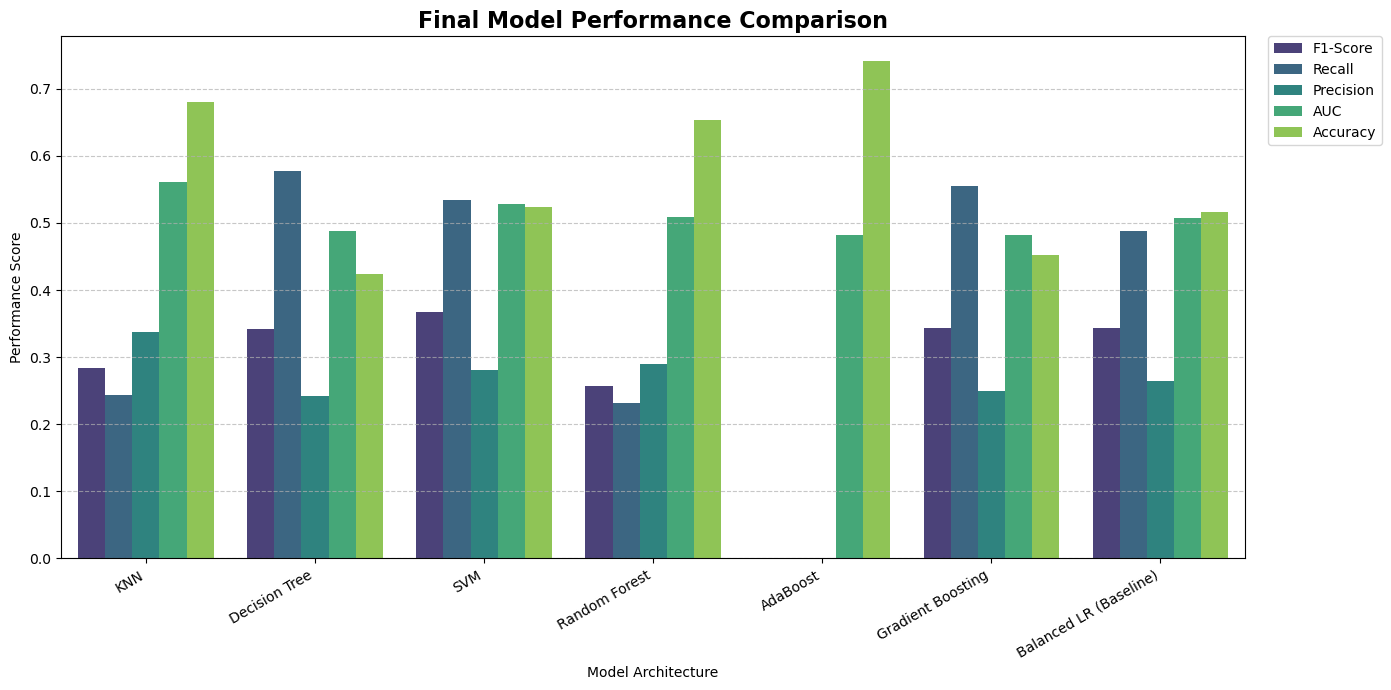

OBSERVATION: Notice that KNN has the highest Accuracy (0.6806) but one of the lowest F1-Scores. This confirms why Accuracy is a misleading metric for this imbalanced dataset.


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Display the sorted table once
print("--- Final Model Comparison: Fewer Features Strategy ---")
display(comparison_df.sort_values(by='F1-Score', ascending=False)
                     .style.highlight_max(axis=0, color='#1DB954')
                     .highlight_min(axis=0, color='#FF4136')
                     .format(precision=4))

# 3. Visualization: Metric Comparison
plt.figure(figsize=(14, 7))
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Final Model Performance Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Performance Score')
plt.xlabel('Model Architecture')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

save_path_chart = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/Final_Model_Comparison_FewerFeatures.png'
plt.savefig(save_path_chart, bbox_inches='tight', dpi=300)
print(f"Chart successfully saved to: {save_path_chart}")

plt.show()

# 4. Summary Observation (Fixed the Model Name lookup to just 'KNN')
knn_accuracy = comparison_df.loc[comparison_df['Model'] == 'KNN', 'Accuracy'].values[0]
print(f"OBSERVATION: Notice that KNN has the highest Accuracy ({knn_accuracy:.4f}) "
      f"but one of the lowest F1-Scores. This confirms why Accuracy is a misleading metric for this imbalanced dataset.")

### Summary 

Reducing the features has not helped improve the model's performance. No model was able to break the 0.37 F1-score barrier, suggesting we reached a "data ceiling."

Since the cost of a False Negative (missing a churner) outweighs a False Positive (nudging a loyal user), the Decision Tree emerged as a functional winner by catching 57.7% of churners, despite its lower accuracy.

### Feature Importance

--- Top 5 Most Influential Features ---


,Feature,Importance
3,skip_rate,0.428110
7,avg_song_length,0.351832
0,age,0.220058
1,listening_time,0.000000
4,ads_listened_per_week,0.000000



--- Top 5 Least Influential Features ---


,Feature,Importance
17,subscription_type_Free,0.0
18,subscription_type_Premium,0.0
19,subscription_type_Student,0.0
20,device_type_Mobile,0.0
21,device_type_Web,0.0


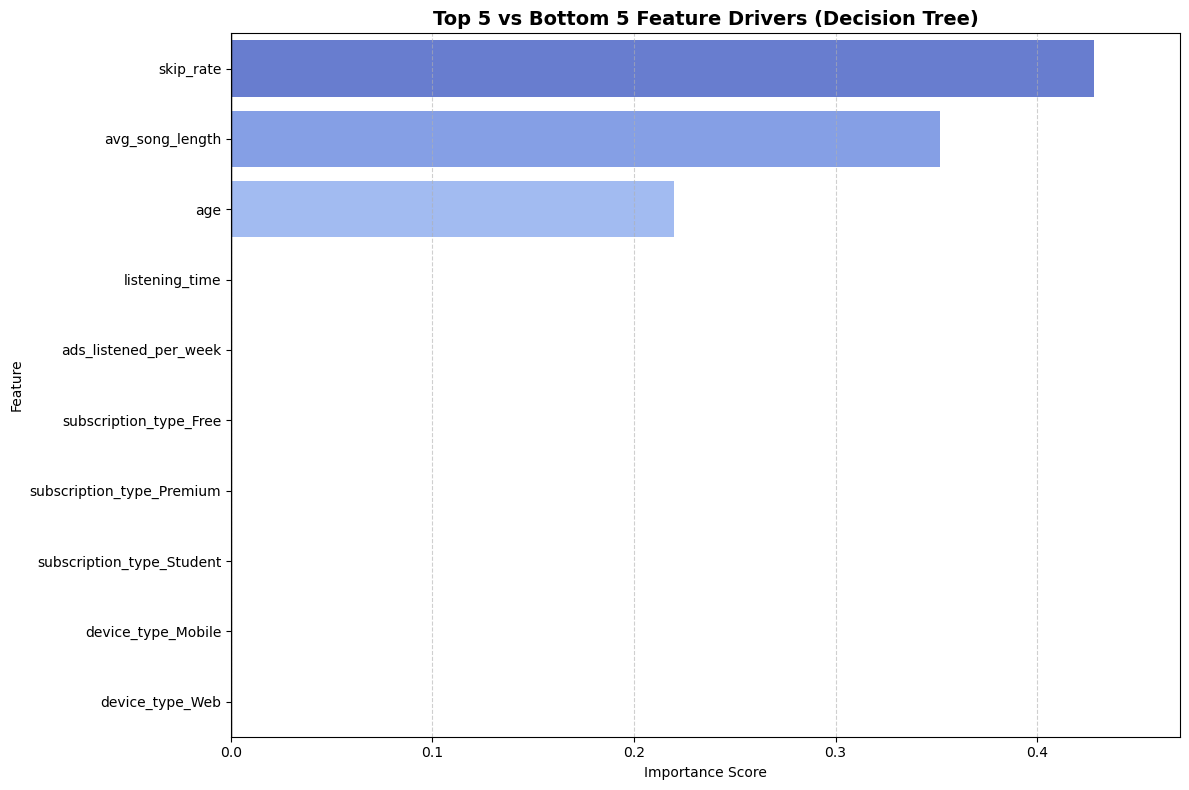

Total features evaluated by Decision Tree: 22


In [55]:
# 1. Get the best Decision Tree model from your grid search
best_dt = dt_grid.best_estimator_.named_steps['dt']

# 2. Get feature names from your training data
feature_names = X_train.columns

# 3. Create a DataFrame to store importances
dt_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Display Results
print("--- Top 5 Most Influential Features ---")
display(dt_importances.head(5))

print("\n--- Top 5 Least Influential Features ---")
display(dt_importances.tail(5))

top_drivers = pd.concat([dt_importances.head(5), dt_importances.tail(5)])

# 6. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=top_drivers, x='Importance', y='Feature', palette='coolwarm', hue='Feature', order=top_drivers['Feature'])

plt.title('Top 5 vs Bottom 5 Feature Drivers (Decision Tree)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Adding a small hint of a line at 0 so the zero-value features are still "there"
plt.xlim(0, top_drivers['Importance'].max() * 1.1)
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
save_path_drivers = os.path.join(viz_folder, 'decision_tree_feature_drivers.png')
plt.savefig(save_path_drivers, bbox_inches='tight', dpi=300)

plt.show()

print(f"Total features evaluated by Decision Tree: {len(dt_importances)}")